# Thực hành Buổi 11: Power BI Dashboard & Storytelling Dữ liệu

**Khóa đào tạo:** Phân tích Dữ liệu Lớn (Big Data Analysis)

**Công cụ:** Power BI Desktop, DAX, Python Integration

**Đầu vào ➔ Đầu ra:** dataset giao dịch sạch (Bài 6) + hồ sơ khách hàng ➔ **file `.pbix` hoàn chỉnh 3 tab báo cáo Executive Overview**

> ⚠️ **Vai trò của notebook này:** Power BI Desktop chạy trên Windows, còn phần "làm dữ liệu" thì làm ở đây. Notebook chuẩn bị **Data Model chuẩn sao (star schema)**, xuất CSV cho Power BI, tính sẵn **bảng số kiểm chứng** (các con số mà measure DAX của bạn PHẢI ra đúng), và viết sẵn script cho **Python visual**. Toàn bộ thao tác trong Power BI Desktop (nạp dữ liệu, tạo quan hệ, viết DAX, dựng 3 tab) làm theo tài liệu `Buoi_11_Huong_Dan_Thuc_Hanh.docx`.

> ⚠️ **Điều kiện tiên quyết:** chạy xong `lab6/Lab6.ipynb` (tạo `enterprise_transactions_clean.parquet` và `customer_churn.csv`).

**Vì sao phải Data Model — không đổ thẳng 1 bảng to vào Power BI?** Mô hình **ngôi sao (star schema)**: một bảng **Fact** (sự kiện, số đo) ở giữa, các bảng **Dimension** (bối cảnh: thời gian, khách hàng, ngành hàng) tỏa ra xung quanh. Lợi ích: DAX đơn giản và đúng ngữ cảnh, slicer lọc mọi biểu đồ nhất quán, file nhẹ và nhanh.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
PBI = PROCESSED / "powerbi"; PBI.mkdir(parents=True, exist_ok=True)

tx = pd.read_parquet(PROCESSED / "enterprise_transactions_clean.parquet")
kh = pd.read_csv(RAW / "customer_churn.csv")
print(f"Giao dịch sạch: {len(tx):,} | Khách hàng: {len(kh):,}")

Giao dịch sạch: 59,985 | Khách hàng: 8,000


## 11.1. Dựng bảng Fact và các bảng Dimension

Sơ đồ ngôi sao của dashboard:

```text
                 DimDate (1.096 ngày)
                       │ 1
                       │
                       ▼ *
DimCustomer 1──* FactSales *──1 DimCategory
 (8.000 KH)      (59.985 dòng)     (6 ngành)
```

`branch`, `channel`, `payment_method`, `status` có rất ít giá trị nên giữ ngay trong Fact (degenerate dimension) — slicer dùng trực tiếp.

In [2]:
# --- FactSales: mỗi dòng một giao dịch, chỉ giữ khóa + số đo ---
fact = pd.DataFrame({
    "transaction_id": tx["transaction_id"],
    "date": tx["ts"].dt.date.astype(str),          # khóa nối DimDate
    "customer_id": tx["customer_id"],
    "category": tx["category"].astype(str),
    "branch": tx["branch"].astype(str),
    "channel": tx["channel"].astype(str),
    "payment_method": tx["payment_method"].astype(str),
    "status": tx["status"].astype(str),
    "quantity": tx["quantity"].astype(int),
    "amount": tx["amount"].round(0).astype("int64"),
    "cost": tx["cost"].round(0).astype("int64"),
    "gio": tx["ts"].dt.hour,
})
print(f"FactSales: {len(fact):,} dòng x {fact.shape[1]} cột")
fact.head(3)

FactSales: 59,985 dòng x 12 cột


,transaction_id,date,customer_id,category,branch,channel,payment_method,status,quantity,amount,cost,gio
0,T0000008,2025-01-01,C05726,Thời trang,Hải Phòng,Online,VI_DIEN_TU,HOAN_TAT,1,11563303,8094312,3
1,T0000001,2025-01-01,C05154,Thực phẩm,TP HCM,Online,THE,HOAN_TAT,3,549000,457913,7
2,T0000002,2025-01-01,C04651,Thực phẩm,Đà Nẵng,Cửa hàng,THE,HOAN_TAT,2,316000,196961,7


In [3]:
# --- DimDate: lịch đầy đủ, KHÔNG ngắt quãng (bắt buộc cho time intelligence DAX) ---
lich = pd.date_range(tx["ts"].min().normalize(), tx["ts"].max().normalize(), freq="D")
ten_thu = ["Thứ 2", "Thứ 3", "Thứ 4", "Thứ 5", "Thứ 6", "Thứ 7", "Chủ nhật"]
dim_date = pd.DataFrame({
    "date": lich.date.astype(str),
    "nam": lich.year,
    "quy": "Q" + lich.quarter.astype(str),
    "thang": lich.month,
    "nam_thang": lich.strftime("%Y-%m"),
    "thu_trong_tuan": [ten_thu[i] for i in lich.dayofweek],
    "so_thu": lich.dayofweek + 1,                  # để Sort by column trong Power BI
    "cuoi_tuan": (lich.dayofweek >= 5).astype(int),
})
print(f"DimDate: {len(dim_date):,} ngày liên tục ({dim_date['date'].iloc[0]} -> {dim_date['date'].iloc[-1]})")
dim_date.head(3)

DimDate: 313 ngày liên tục (2025-01-01 -> 2025-11-09)


,date,nam,quy,thang,nam_thang,thu_trong_tuan,so_thu,cuoi_tuan
0,2025-01-01,2025,Q1,1,2025-01,Thứ 4,3,0
1,2025-01-02,2025,Q1,1,2025-01,Thứ 5,4,0
2,2025-01-03,2025,Q1,1,2025-01,Thứ 6,5,0


In [4]:
# --- DimCustomer: hồ sơ + phân khúc RFM (rút gọn từ Bài 7) ---
tx_ht = tx[tx["status"] == "HOAN_TAT"]
moc = tx_ht["ts"].max() + pd.Timedelta(days=1)
rfm = (tx_ht.groupby("customer_id")
       .agg(recency=("ts", lambda s: (moc - s.max()).days),
            frequency=("transaction_id", "size"),
            monetary=("amount", "sum")))
rfm["R"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5,
                   labels=[1, 2, 3, 4, 5]).astype(int)
phan_khuc = np.select(
    [(rfm["R"] >= 4) & (rfm["F"] >= 4), (rfm["R"] >= 4) & (rfm["F"] <= 2),
     (rfm["R"] <= 2) & (rfm["F"] >= 4), (rfm["R"] <= 2) & (rfm["F"] <= 2)],
    ["Khách VIP", "Khách mới", "Nguy cơ rời bỏ", "Đã ngủ đông"], "Trung bình")
rfm["phan_khuc"] = phan_khuc

dim_customer = (kh.set_index("customer_id")
                  .join(rfm[["recency", "frequency", "monetary", "phan_khuc"]])
                  .reset_index())
dim_customer["phan_khuc"] = dim_customer["phan_khuc"].fillna("Chưa mua")
dim_customer["trang_thai"] = np.where(dim_customer["churn"] == 1, "Đã rời bỏ", "Đang hoạt động")
print(f"DimCustomer: {len(dim_customer):,} khách hàng")
dim_customer.head(3)

DimCustomer: 8,000 khách hàng


,customer_id,age,gender,city,tenure_months,support_tickets,churn,recency,frequency,monetary,phan_khuc,trang_thai
0,C00001,47,Nữ,Hà Nội,15,1,0,1.0,643.0,6.281849e+08,Khách VIP,Đang hoạt động
1,C00002,32,Nam,Đà Nẵng,20,2,0,1.0,439.0,4.224040e+08,Khách VIP,Đang hoạt động
2,C00003,38,Nam,Cần Thơ,54,1,0,1.0,344.0,3.707431e+08,Khách VIP,Đang hoạt động


In [5]:
# --- DimCategory: 6 ngành hàng + nhóm biên lợi nhuận (thuộc tính mô tả) ---
dim_category = (tx_ht.groupby("category", observed=True)
                .agg(doanh_thu=("amount", "sum"), chi_phi=("cost", "sum"))
                .reset_index())
dim_category["bien_ln"] = (1 - dim_category["chi_phi"] / dim_category["doanh_thu"]).round(3)
dim_category["nhom_bien_ln"] = np.where(dim_category["bien_ln"] >= dim_category["bien_ln"].median(),
                                        "Biên cao", "Biên thấp")
dim_category = dim_category[["category", "nhom_bien_ln"]]
dim_category

,category,nhom_bien_ln
0,Gia dụng,Biên cao
1,Mỹ phẩm,Biên thấp
2,Sách,Biên thấp
3,Thời trang,Biên cao
4,Thực phẩm,Biên cao
5,Điện tử,Biên cao


## 11.2. Kiểm tra chất lượng mô hình trước khi xuất

Ba điều kiện của một star schema lành mạnh — vi phạm điều nào Power BI cũng sẽ tạo quan hệ many-to-many hoặc ra số sai:

1. Khóa của mỗi Dimension phải **duy nhất**;
2. Mọi khóa ngoại trong Fact phải **tồn tại** trong Dimension (toàn vẹn tham chiếu);
3. DimDate phải **liên tục** không ngắt quãng.

In [6]:
kiem_tra = [
    ["DimDate.date duy nhất",        dim_date["date"].is_unique],
    ["DimCustomer.customer_id duy nhất", dim_customer["customer_id"].is_unique],
    ["DimCategory.category duy nhất",  dim_category["category"].is_unique],
    ["Fact.date đều có trong DimDate", fact["date"].isin(dim_date["date"]).all()],
    ["Fact.customer_id đều có trong DimCustomer",
     fact["customer_id"].isin(dim_customer["customer_id"]).all()],
    ["Fact.category đều có trong DimCategory",
     fact["category"].isin(dim_category["category"]).all()],
    ["DimDate liên tục không ngắt quãng",
     len(dim_date) == (pd.to_datetime(dim_date['date']).max()
                       - pd.to_datetime(dim_date['date']).min()).days + 1],
]
for ten, ok in kiem_tra:
    print(f"  {'[DAT]' if ok else '[LOI]'}  {ten}")
assert all(ok for _, ok in kiem_tra)
print("\nMô hình đạt cả 3 điều kiện — sẵn sàng xuất cho Power BI.")

  [DAT]  DimDate.date duy nhất
  [DAT]  DimCustomer.customer_id duy nhất
  [DAT]  DimCategory.category duy nhất
  [DAT]  Fact.date đều có trong DimDate
  [DAT]  Fact.customer_id đều có trong DimCustomer
  [DAT]  Fact.category đều có trong DimCategory
  [DAT]  DimDate liên tục không ngắt quãng

Mô hình đạt cả 3 điều kiện — sẵn sàng xuất cho Power BI.


## 11.3. Xuất CSV cho Power BI

Mã hóa `utf-8-sig` (UTF-8 có BOM) để Power BI đọc đúng tiếng Việt ngay từ hộp thoại Get Data.

In [7]:
for ten, bang in [("FactSales", fact), ("DimDate", dim_date),
                  ("DimCustomer", dim_customer), ("DimCategory", dim_category)]:
    duong_dan = PBI / f"{ten}.csv"
    bang.to_csv(duong_dan, index=False, encoding="utf-8-sig")
    print(f"  {ten:<12}{len(bang):>8,} dòng  ->  {duong_dan}")
print("\nMở Power BI Desktop -> Get Data -> Text/CSV -> nạp cả 4 tệp này.")

  FactSales     59,985 dòng  ->  ../data/processed/powerbi/FactSales.csv
  DimDate          313 dòng  ->  ../data/processed/powerbi/DimDate.csv


  DimCustomer    8,000 dòng  ->  ../data/processed/powerbi/DimCustomer.csv
  DimCategory        6 dòng  ->  ../data/processed/powerbi/DimCategory.csv

Mở Power BI Desktop -> Get Data -> Text/CSV -> nạp cả 4 tệp này.


## 11.4. Bảng số kiểm chứng — DAX của bạn PHẢI ra đúng các con số này

Nguyên tắc nghề nghiệp: **không bao giờ tin một dashboard chưa được đối chiếu**. Học viên dựng xong measure nào thì so ngay với bảng dưới; lệch một đồng là ngữ cảnh lọc (filter context) đang sai.

In [8]:
ht = fact[fact["status"] == "HOAN_TAT"]
doanh_thu = ht["amount"].sum(); chi_phi = ht["cost"].sum()
bang_kiem_chung = pd.DataFrame([
    ["Tong Doanh Thu (HOAN_TAT)",  f"{doanh_thu:,.0f} đ"],
    ["Tong Chi Phi",               f"{chi_phi:,.0f} đ"],
    ["Loi Nhuan Gop",              f"{doanh_thu - chi_phi:,.0f} đ"],
    ["Bien LN Gop",                f"{1 - chi_phi/doanh_thu:.2%}"],
    ["So Don Hoan Tat",            f"{len(ht):,}"],
    ["AOV",                        f"{doanh_thu/len(ht):,.0f} đ"],
    ["So Khach Hoat Dong",         f"{ht['customer_id'].nunique():,}"],
    ["Ty Le Hoan Tra",             f"{(fact['status'] == 'HOAN_TRA').mean():.2%}"],
    ["Churn Rate",                 f"{dim_customer['churn'].mean():.1%}"],
    ["Doanh thu thang cao nhat",
     (ht.assign(nt=ht['date'].str[:7]).groupby('nt')['amount'].sum().idxmax()
      + f" ({ht.assign(nt=ht['date'].str[:7]).groupby('nt')['amount'].sum().max():,.0f} đ)")],
], columns=["Measure", "Giá trị PHẢI ra"])
print(bang_kiem_chung.to_string(index=False))
bang_kiem_chung.to_csv(PBI / "bang_kiem_chung.csv", index=False, encoding="utf-8-sig")

                  Measure           Giá trị PHẢI ra
Tong Doanh Thu (HOAN_TAT)          60,455,690,548 đ
             Tong Chi Phi          43,606,982,674 đ
            Loi Nhuan Gop          16,848,707,874 đ
              Bien LN Gop                    27.87%
          So Don Hoan Tat                    57,882
                      AOV               1,044,464 đ
       So Khach Hoat Dong                     7,858
           Ty Le Hoan Tra                     3.51%
               Churn Rate                     35.1%
 Doanh thu thang cao nhat 2025-01 (6,123,717,240 đ)


## 11.5. Python Integration — script cho Python visual trong Power BI

Power BI cho phép một visual chạy Python: kéo các trường vào visual, Power BI đưa chúng cho script dưới dạng DataFrame tên **`dataset`**, script vẽ bằng matplotlib. Ô dưới đây **mô phỏng** đúng cơ chế đó (tạo `dataset` rồi chạy y nguyên script) — script trong khối `SCRIPT_PYTHON_VISUAL` là thứ bạn dán vào Power BI ở Tab 3.

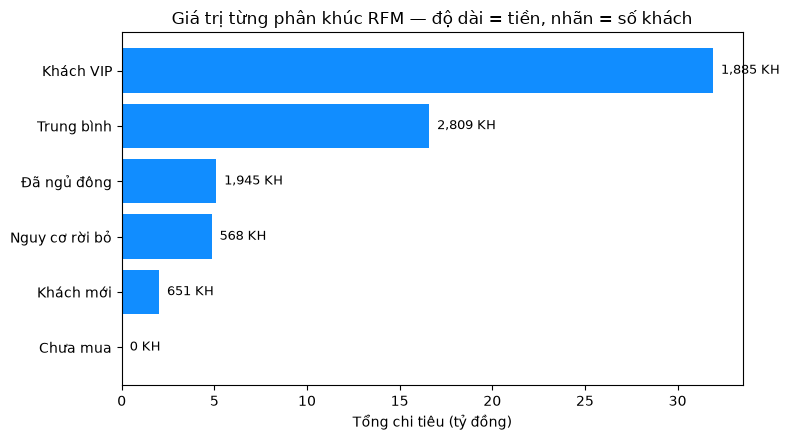

In [9]:
# Mô phỏng: Power BI sẽ đưa 2 cột phan_khuc, monetary vào `dataset`
dataset = dim_customer[["phan_khuc", "monetary"]].copy()

SCRIPT_PYTHON_VISUAL = '''
# === Dán nguyên khối này vào Python visual của Power BI (Tab 3) ===
import matplotlib.pyplot as plt
import pandas as pd

df = dataset.groupby("phan_khuc")["monetary"].agg(["count", "sum"])
df = df.sort_values("sum")
fig, ax = plt.subplots(figsize=(8, 4.5))
thanh = ax.barh(df.index, df["sum"] / 1e9, color="#118DFF")
for i, (so_kh, tong) in enumerate(zip(df["count"], df["sum"] / 1e9)):
    ax.text(tong, i, f"  {so_kh:,.0f} KH", va="center", fontsize=9)
ax.set_xlabel("Tổng chi tiêu (tỷ đồng)")
ax.set_title("Giá trị từng phân khúc RFM — độ dài = tiền, nhãn = số khách")
plt.tight_layout()
plt.show()
'''
exec(SCRIPT_PYTHON_VISUAL)

---
## TỔNG KẾT — VIỆC CỦA BẠN TRONG POWER BI DESKTOP

Notebook đã xong phần dữ liệu. Theo tài liệu hướng dẫn (docx) để hoàn thành deliverable:

| Bước | Việc làm | Tài liệu mục |
|:---|:---|:---|
| 1 | Get Data ➔ nạp 4 CSV trong `data/processed/powerbi/` | §2.1 |
| 2 | Model view ➔ tạo 3 quan hệ 1-* về FactSales; Mark as date table | §2.2 |
| 3 | Viết 10 measure DAX (bảng công thức đầy đủ trong tài liệu) | §2.3 |
| 4 | Dựng 3 tab: Executive Overview ➔ Phân tích bán hàng ➔ Khách hàng & Churn | §2.4 |
| 5 | Đối chiếu từng số với `bang_kiem_chung.csv` | §2.5 |
| 6 | Nộp file `.pbix` | §3 |

---
# BÀI TẬP VỀ NHÀ

#### Bài tập 1 (Data Model): Bổ sung bảng `DimBranch` (branch ➔ mien: Bắc/Trung/Nam) ngay trong notebook này, kiểm tra toàn vẹn tham chiếu như mục 11.2 rồi xuất CSV. Trong Power BI, tạo quan hệ và thêm slicer theo miền vào Tab 1.

In [10]:
# --- BÀI TẬP 1 ---


#### Bài tập 2 (Kiểm chứng): Tính thêm 3 con số kiểm chứng cho DAX: doanh thu kênh Online năm 2025, AOV của riêng "Khách VIP", và tỷ lệ hoàn trả theo từng ngành hàng. Viết 3 measure DAX tương ứng trong Power BI và đối chiếu.

In [11]:
# --- BÀI TẬP 2 ---
